# FFT / DCT Frequency Filters

## Goals

- Apply Low-Pass Filter
- Apply High-Pass Filter
- Apply Band-Pass Filter
- Compare FFT and DCT filtering
- Focus on the Y (luminance) channel

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from scipy.fft import dctn, idctn


import os

print(os.getcwd())

d:\Works\projects\Private\FrequencyVisionLab\notebooks


* Setup Images 

In [3]:
IMAGE_PATHS = [
    "imgs/test0.jpg",
    "imgs/test1.jpg",
    "imgs/test_blur0.jpg",
    "imgs/test_blur1.jpg",
]

images = []

for path in IMAGE_PATHS:
    image = cv2.imread(path)

    if image is None:
        raise FileNotFoundError(path)

    # BGR -> RGB for matplotlib display
    rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # BGR -> YCrCb
    ycrcb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2YCrCb
    )

    # Split luminance and chroma channels
    y, cr, cb = cv2.split(ycrcb)

    images.append({
        "path": path,
        "bgr": image,
        "rgb": rgb,
        "ycrcb": ycrcb,
        "y": y,
        "cr": cr,
        "cb": cb,
    })

In [4]:
def show_comparison(original, processed, title):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original, cmap="gray")
    plt.title("Original Y")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(processed, cmap="gray")
    plt.title(title)
    plt.axis("off")

    plt.show()

FFT -> IFFT with Filter (low/high/band)

In [ ]:
def fft_filter(
    image,
    filter_type="low",
    low_radius=20, # default cycles/pixel like HZ (cycles/second)
    high_radius=80  # default cycles/pixel like HZ (cycles/second)
):
    h, w = image.shape
    cy, cx = h // 2, w // 2

    # 2D FFT: Spatial Domain → Frequency Domain
    fft = np.fft.fft2(image)
    fft_shift = np.fft.fftshift(fft)

    # Distance from frequency center
    y, x = np.ogrid[:h, :w]

    distance = np.sqrt(
        (x - cx) ** 2 +
        (y - cy) ** 2
    )

    # Frequency mask (Low/High/Band)
    if filter_type == "low":
        mask = distance <= high_radius

    elif filter_type == "high":
        mask = distance >= low_radius

    elif filter_type == "band":
        mask = (
            (distance >= low_radius) &
            (distance <= high_radius)
        )

    else:
        raise ValueError(
            "filter_type must be low, high or band"
        )

    # Apply mask with Filter 
    filtered_fft = fft_shift * mask

    # IFFT: Frequency Domain → Spatial Domain
    fft_ishift = np.fft.ifftshift(
        filtered_fft
    )

    reconstructed = np.fft.ifft2(
        fft_ishift
    )

    return np.real(reconstructed), mask

DCT -> IDCT with Filter (low/high/band)

In [ ]:
def dct_filter(
    image,
    filter_type="low",
    low_ratio=0.05, # default cycles/pixel like HZ (cycles/second)
    high_ratio=0.25  # default cycles/pixel like HZ (cycles/second)
):
    image_float = image.astype(
        np.float32
    )

    # DCT: Spatial Domain → Frequency Domain
    coefficients = dctn(
        image_float,
        type=2,
        norm="ortho"
    )

    h, w = coefficients.shape

    y, x = np.ogrid[:h, :w]

    # Distance from DCT DC component (upper-left)
    distance = np.sqrt(
        (x / max(w - 1, 1)) ** 2 +
        (y / max(h - 1, 1)) ** 2
    )

    # Frequency mask
    if filter_type == "low":
        mask = distance <= high_ratio

    elif filter_type == "high":
        mask = distance >= low_ratio

    elif filter_type == "band":
        mask = (
            (distance >= low_ratio) &
            (distance <= high_ratio)
        )

    else:
        raise ValueError(
            "filter_type must be low, high or band"
        )

    # Apply mask
    filtered_coefficients = (
        coefficients * mask
    )

    # IDCT: Frequency Domain → Spatial Domain
    reconstructed = idctn(
        filtered_coefficients,
        type=2,
        norm="ortho"
    )

    return reconstructed, mask

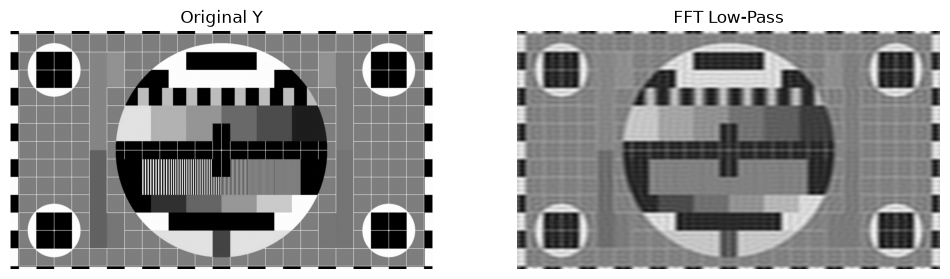

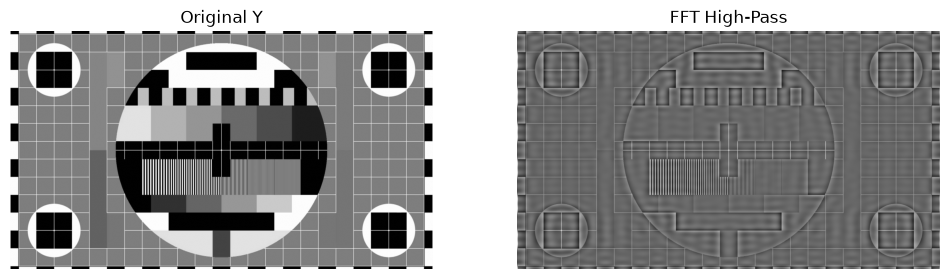

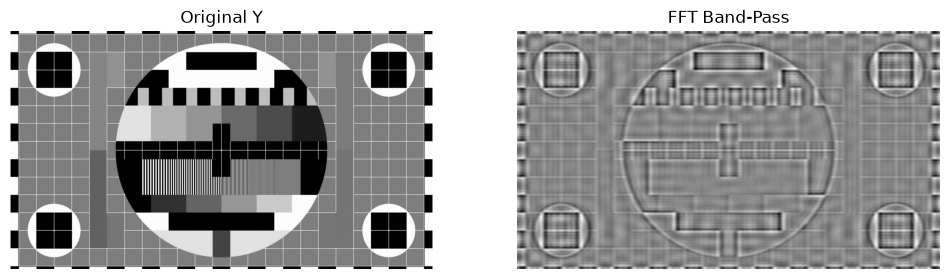

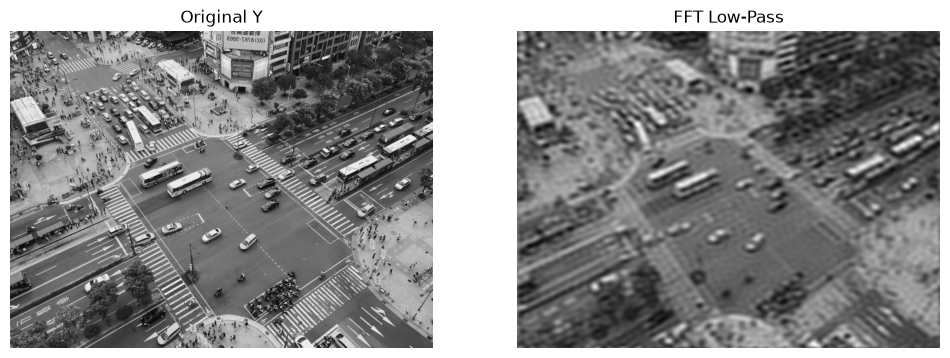

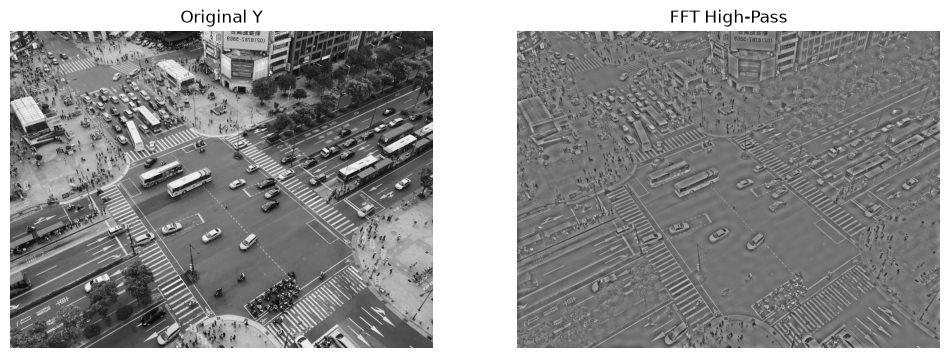

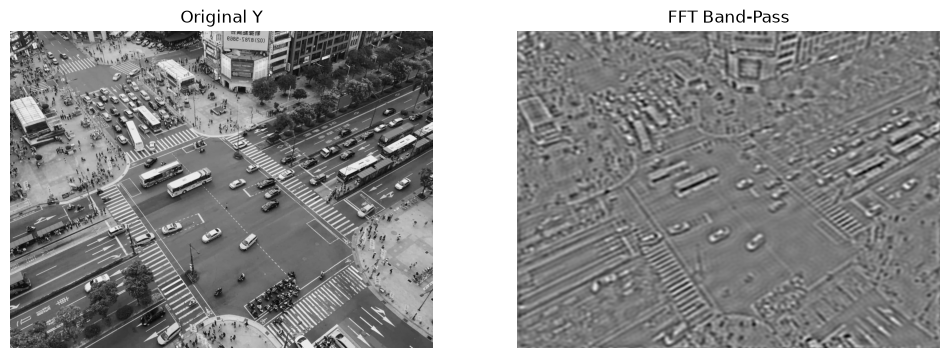

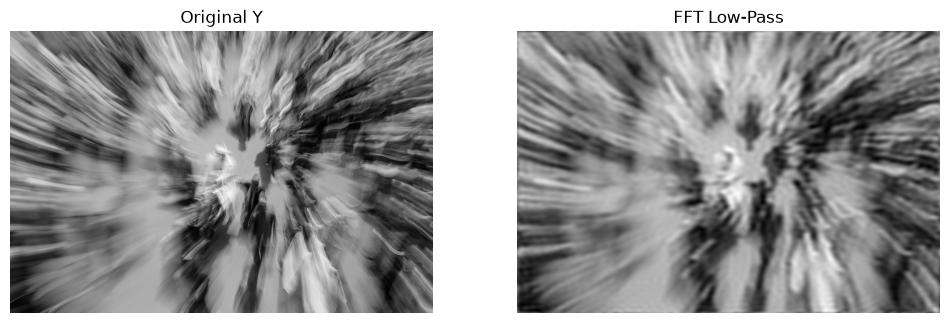

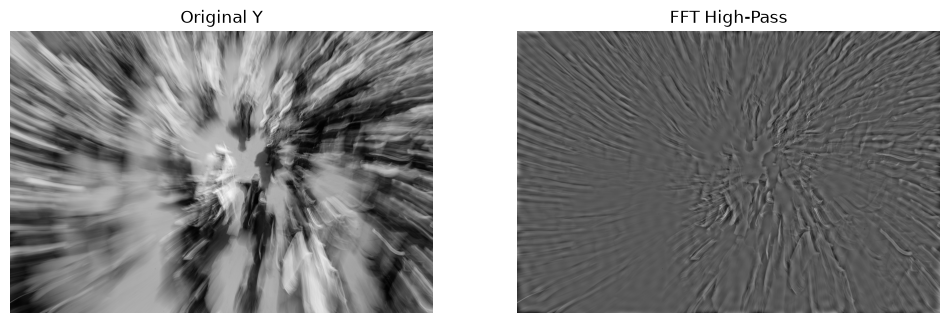

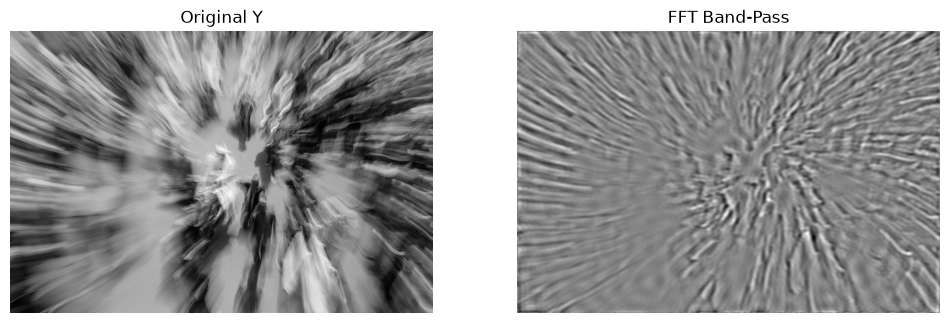

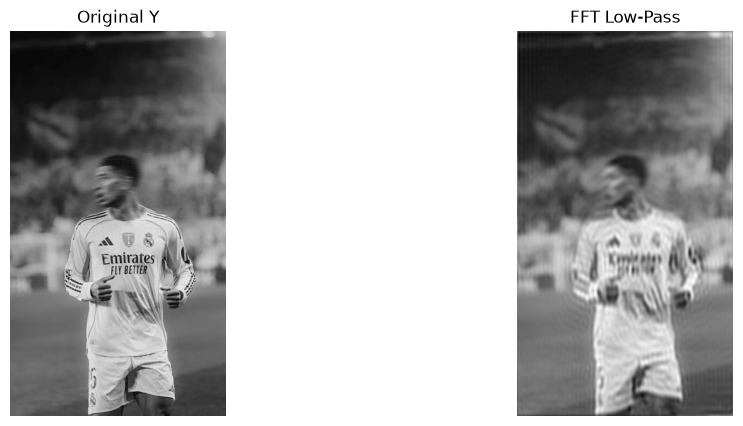

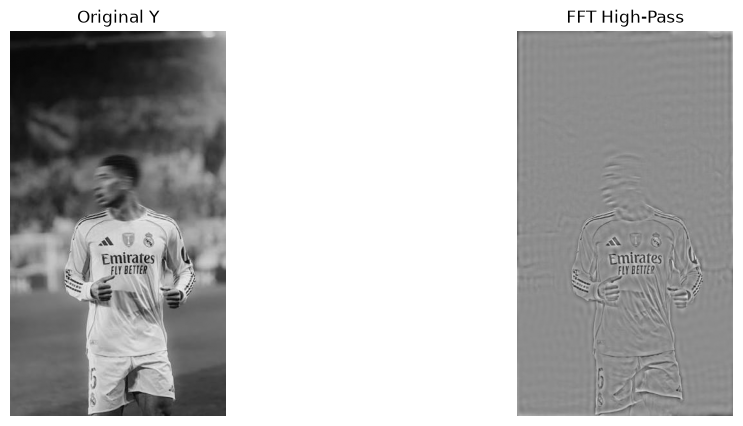

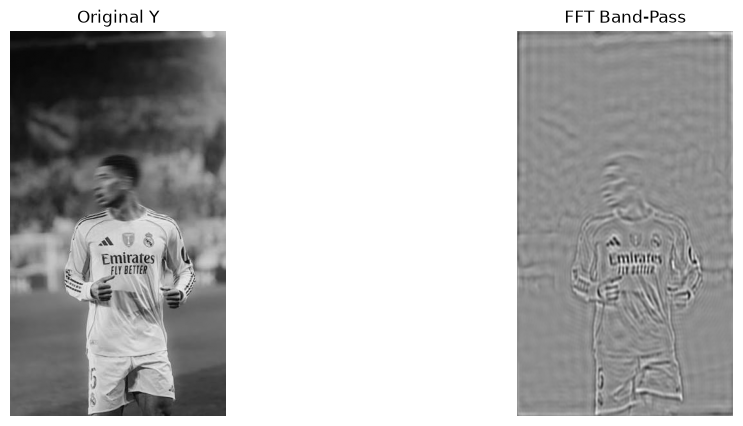

In [ ]:
for item in images:
    y = item["y"]

    low_pass, _ = fft_filter(
        y,
        filter_type="low",
        high_radius=50  # cycles/pixel like HZ (cycles/second)
    )

    high_pass, _ = fft_filter(
        y,
        filter_type="high",
        low_radius=30  # cycles/pixel like HZ (cycles/second)
    )

    band_pass, _ = fft_filter(
        y,
        filter_type="band",
        low_radius=20,  # cycles/pixel like HZ (cycles/second)
        high_radius=80  # cycles/pixel like HZ (cycles/second)
    )

    show_comparison(
        y,
        low_pass,
        "FFT Low-Pass"
    )

    show_comparison(
        y,
        high_pass,
        "FFT High-Pass"
    )

    show_comparison(
        y,
        band_pass,
        "FFT Band-Pass"
    )

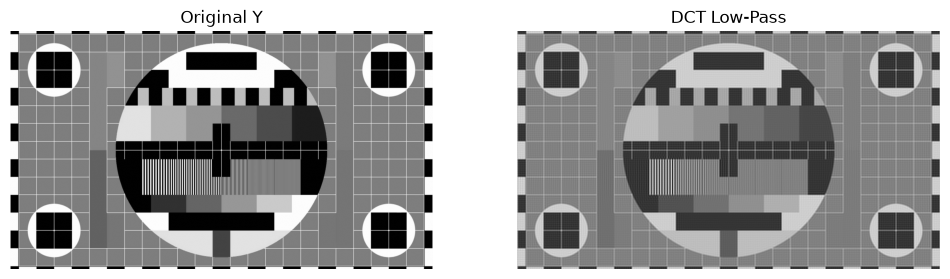

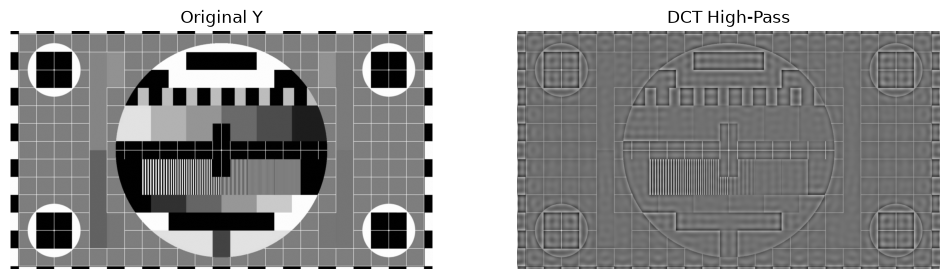

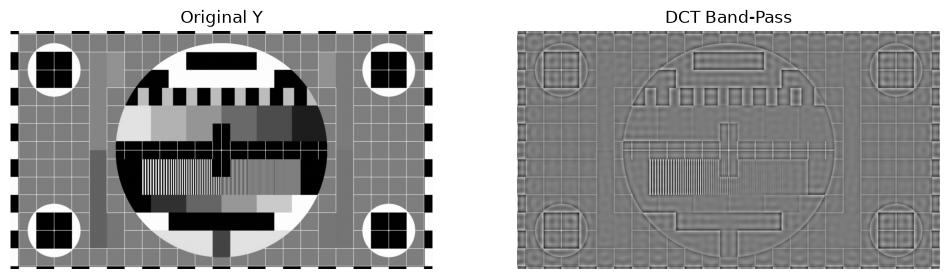

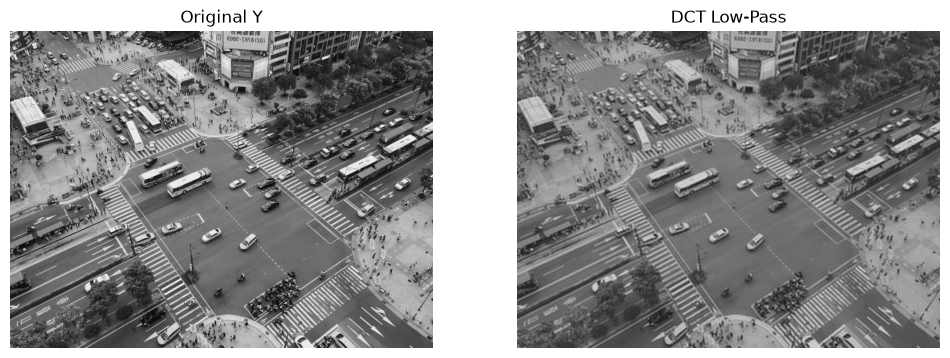

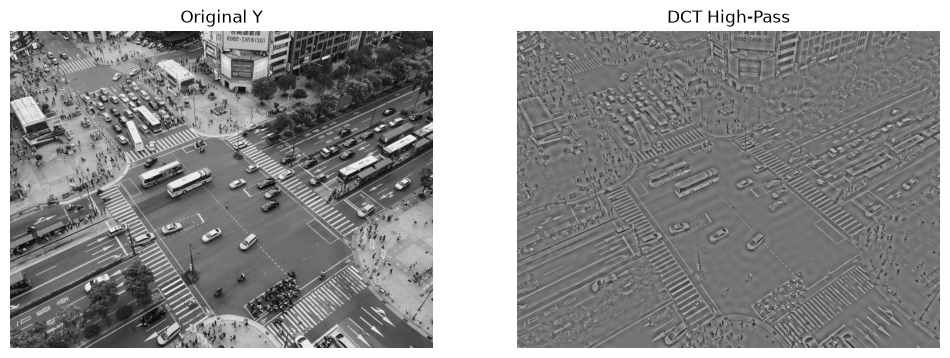

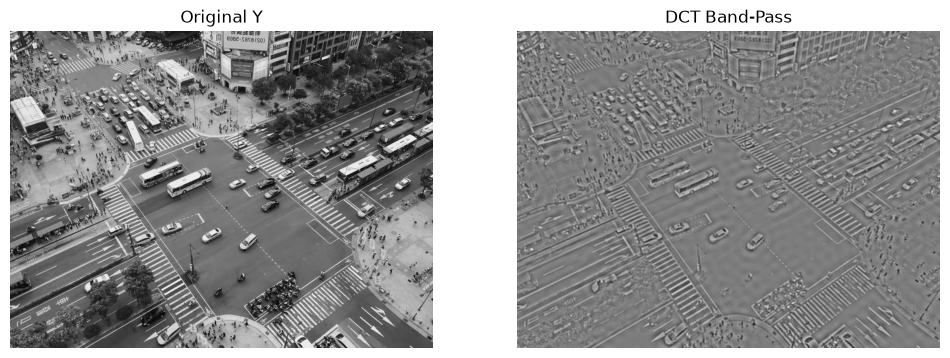

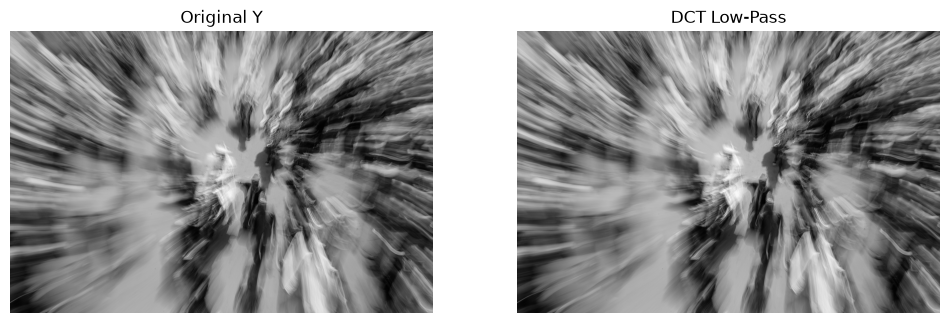

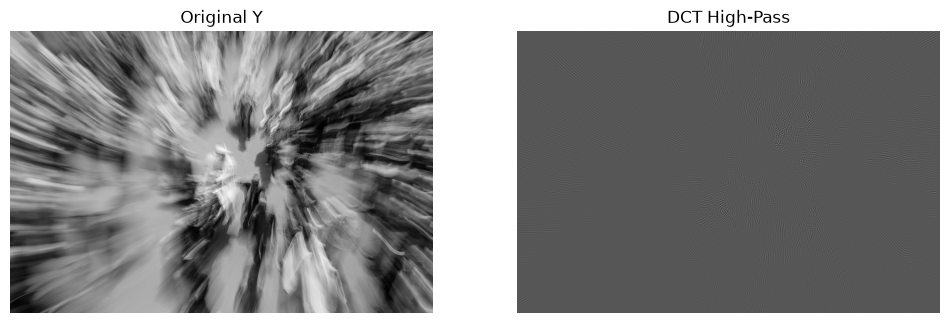

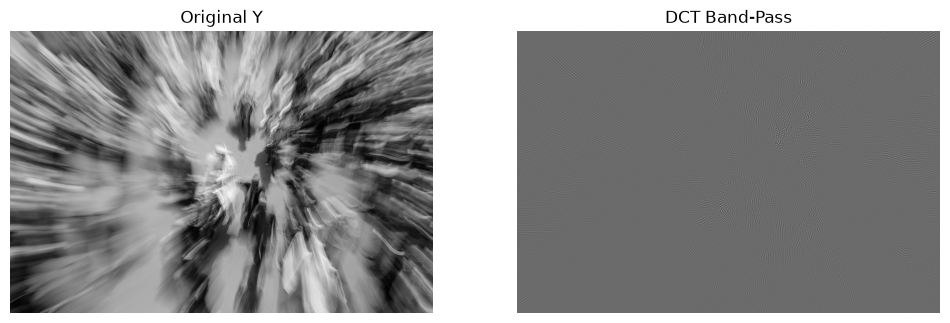

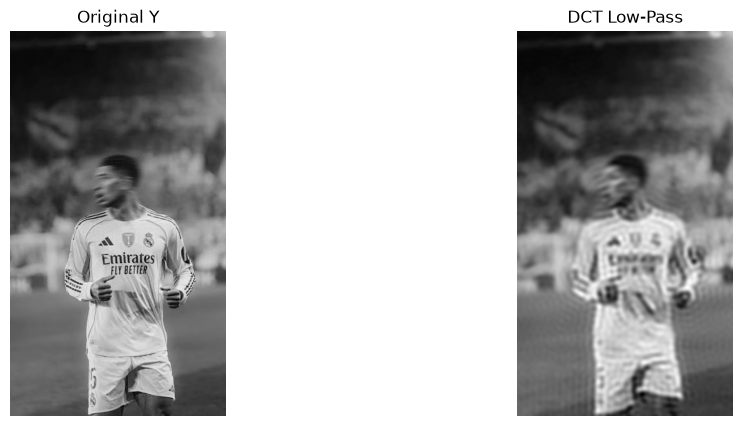

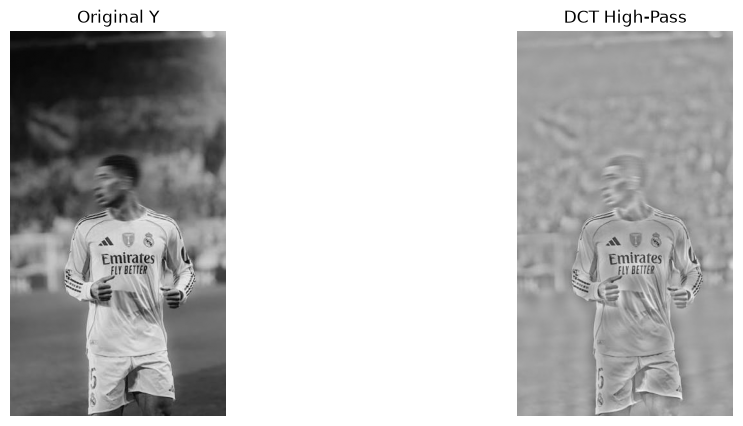

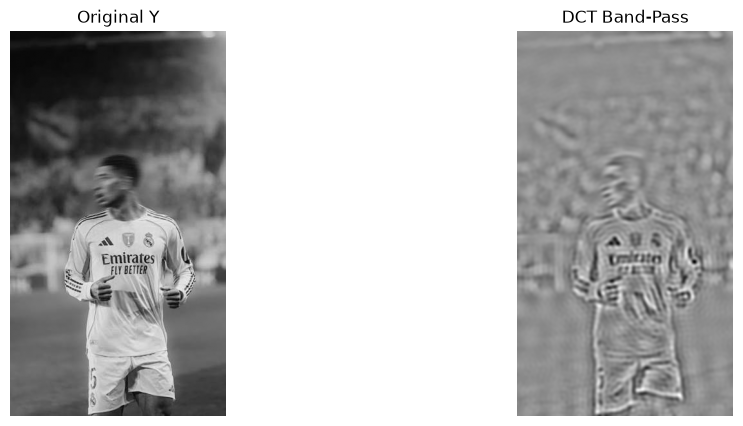

In [ ]:
for item in images:
    y = item["y"]

    low_pass, _ = dct_filter(
        y,
        filter_type="low",
        high_ratio=0.20
    )

    high_pass, _ = dct_filter(
        y,
        filter_type="high",
        low_ratio=0.05  # cycles/pixel like HZ (cycles/second)
    )

    band_pass, _ = dct_filter(
        y,
        filter_type="band",
        low_ratio=0.05,
        high_ratio=0.25
    )

    show_comparison(
        y,
        low_pass,
        "DCT Low-Pass"
    )

    show_comparison(
        y,
        high_pass,
        "DCT High-Pass"
    )

    show_comparison(
        y,
        band_pass,
        "DCT Band-Pass"
    )

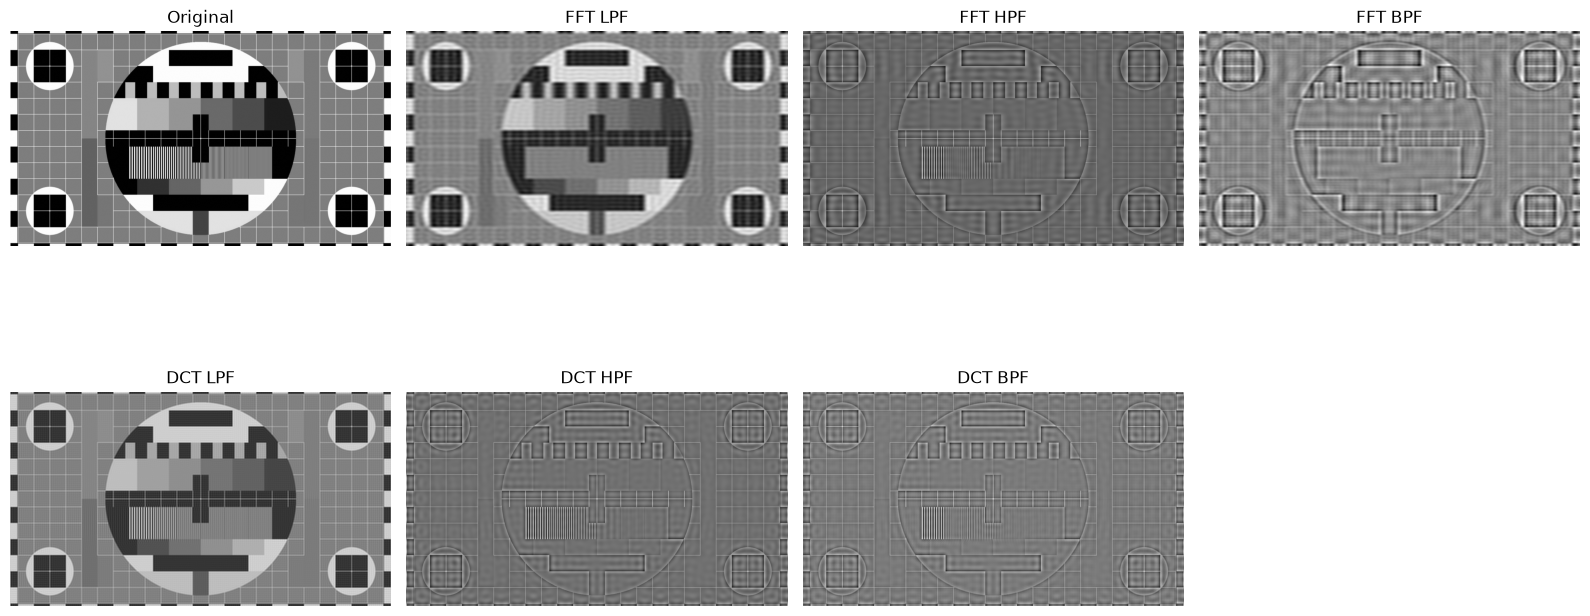

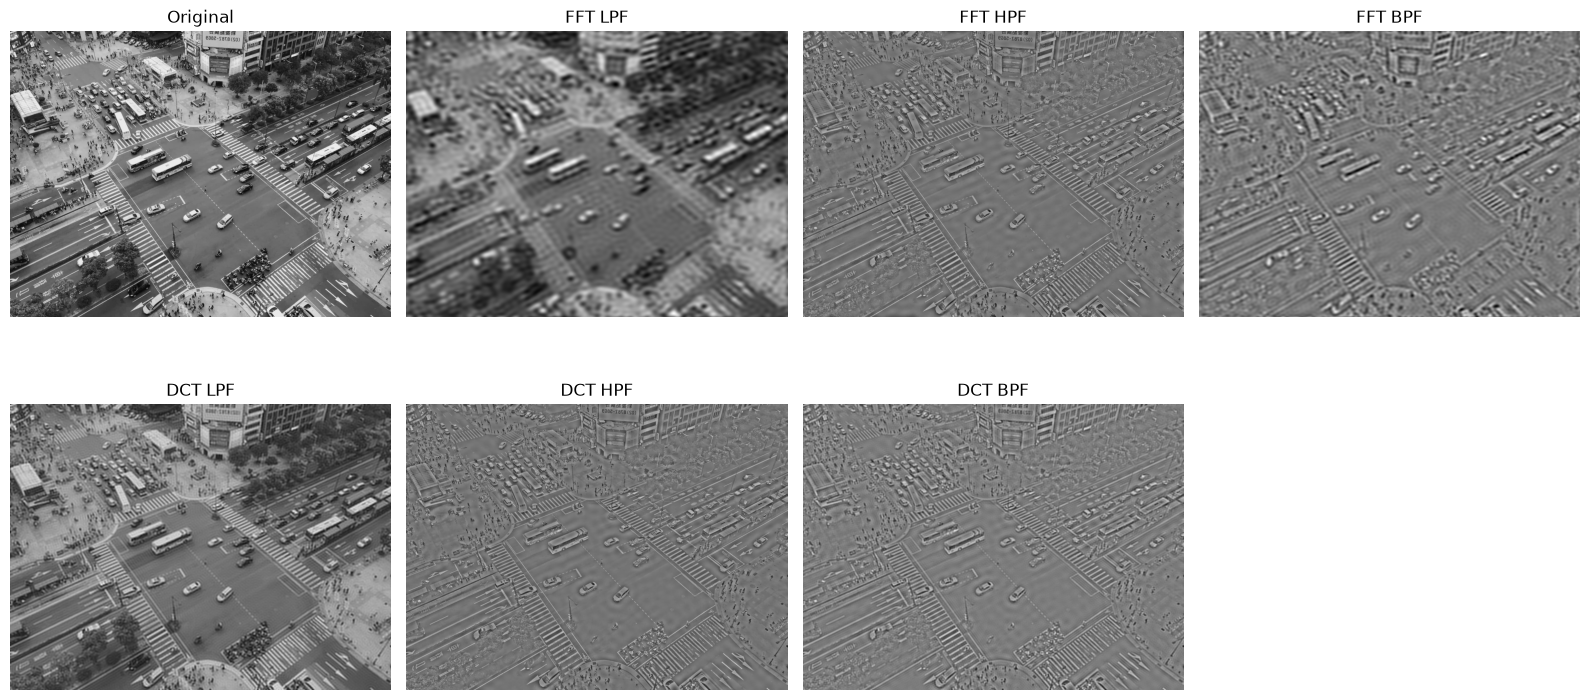

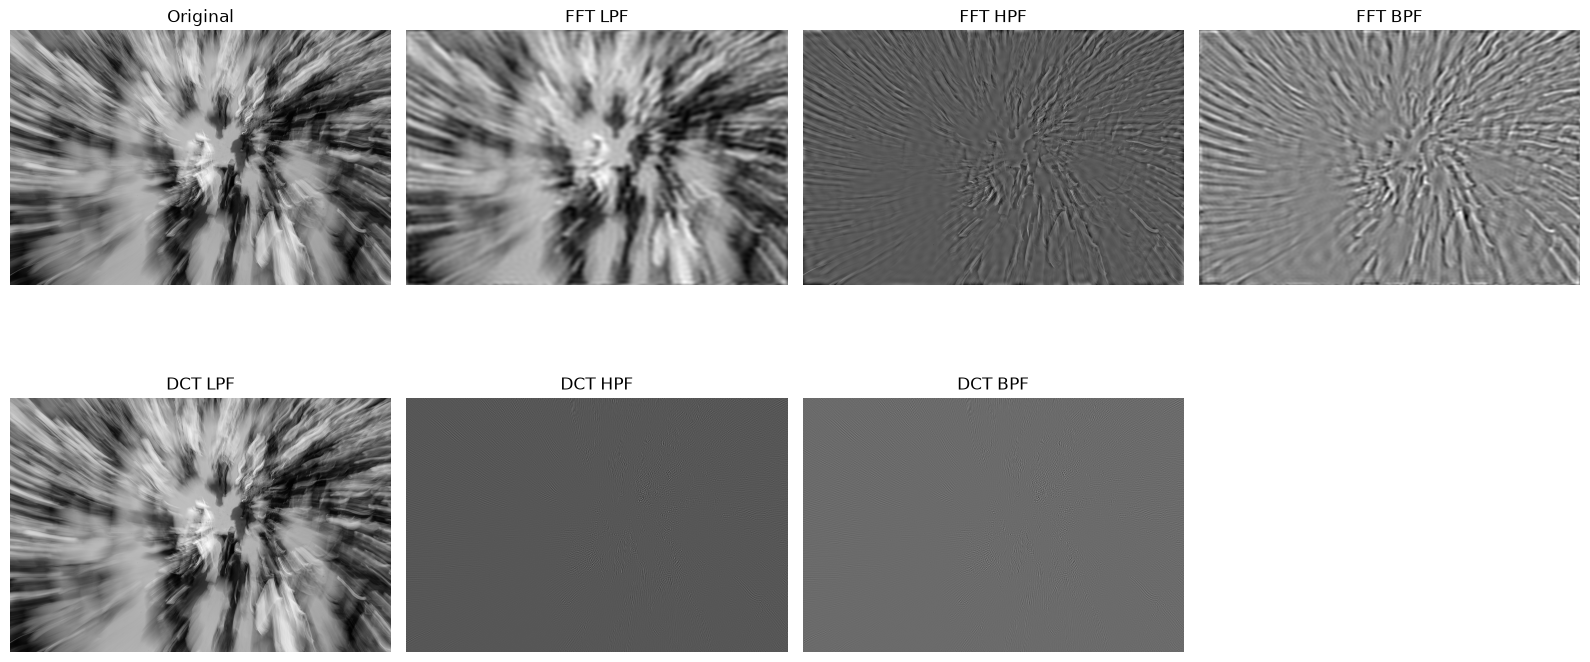

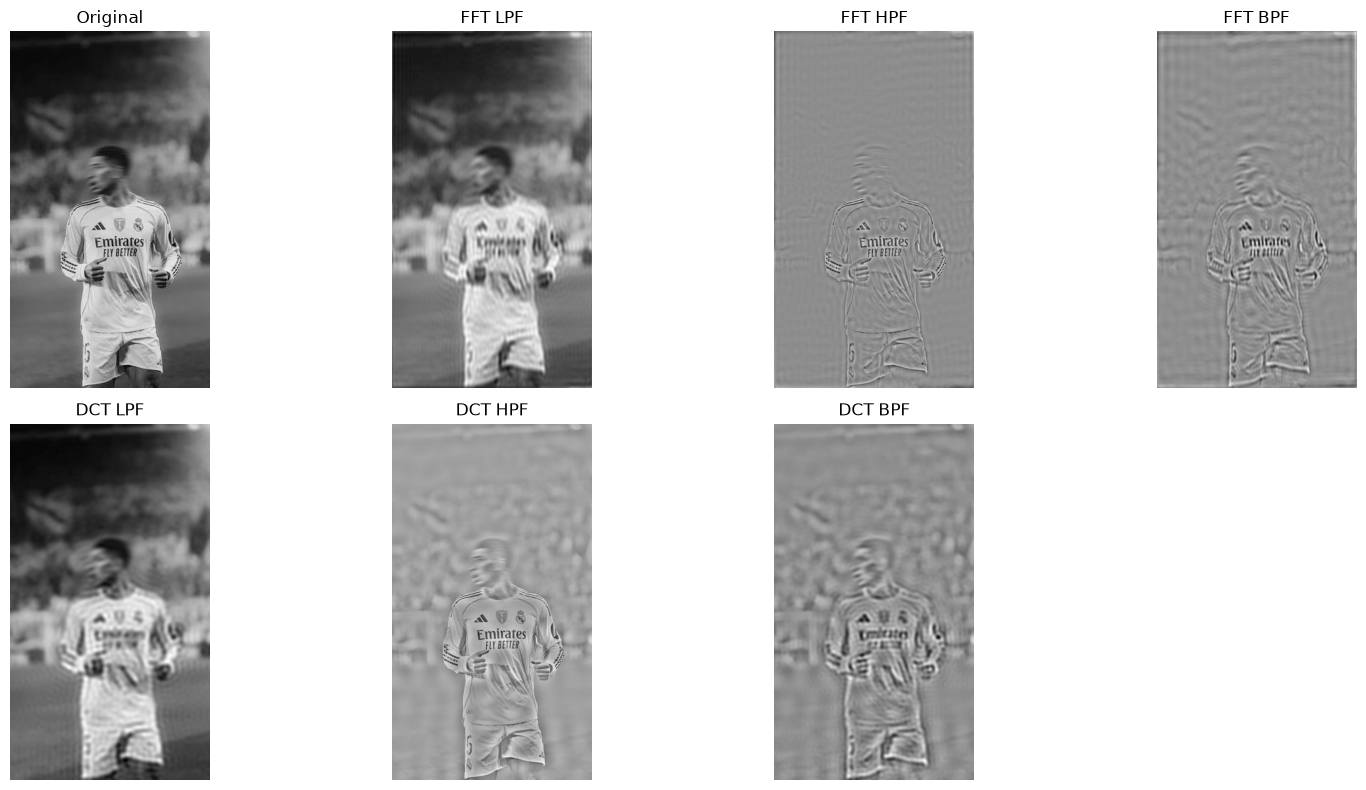

In [9]:
for item in images:
    y = item["y"]

    fft_lpf, _ = fft_filter(
        y,
        "low",
        high_radius=50
    )

    fft_hpf, _ = fft_filter(
        y,
        "high",
        low_radius=30
    )

    fft_bpf, _ = fft_filter(
        y,
        "band",
        low_radius=20,
        high_radius=80
    )

    dct_lpf, _ = dct_filter(
        y,
        "low",
        high_ratio=0.20
    )

    dct_hpf, _ = dct_filter(
        y,
        "high",
        low_ratio=0.05
    )

    dct_bpf, _ = dct_filter(
        y,
        "band",
        low_ratio=0.05,
        high_ratio=0.25
    )

    results = [
        ("Original", y),
        ("FFT LPF", fft_lpf),
        ("FFT HPF", fft_hpf),
        ("FFT BPF", fft_bpf),
        ("DCT LPF", dct_lpf),
        ("DCT HPF", dct_hpf),
        ("DCT BPF", dct_bpf),
    ]

    plt.figure(figsize=(16, 8))

    for index, (title, result) in enumerate(
        results,
        start=1
    ):
        plt.subplot(2, 4, index)

        plt.imshow(
            result,
            cmap="gray"
        )

        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()